# Reference Program Simulator (Probability Density Function)

See the [Logbook: Results Verification](../Log_Verify.md) document for interpretation of results.

### Quick Start

1. To use this ipynb file, you need to have installed the Jupyter Notebook kernel.
2. Put this file and the *.mem files into the same folder and run all cells.
3. Scroll to bottom for simulation results for both the single cycle and pipelined results.

### If Failed To Use Jupyter Notebook

1. Run `python pdf.py` to run the script on its own.
2. View results in the `img` directory.


In [42]:
from typing import TextIO, List
import matplotlib.pyplot as plt

In [43]:
def process_file(file: TextIO) -> List[str]:
    data = []
    for line in file:
        line = line[:-1]
        line = line.split(' ')
        data += line
    return data

gaussian = process_file(open("gaussian.mem", "r"))
noisy = process_file(open("noisy.mem", "r"))
sine = process_file(open("sine.mem", "r"))
triangle = process_file(open("triangle.mem", "r"))

In [44]:
def process_data(data: List[str], max: int = 255) -> List[int]:
    pdf = [0] * 255 # 0x00 to 0xFF
    max_count = 0
    while max_count <= max:
        for item in data:
            if item == "": continue
            num = int(item, 16)
            pdf[num] += 1
            if pdf[num] > max:
                return pdf
    return pdf

gaussian_pdf = process_data(gaussian)
noisy_pdf = process_data(noisy)
sine_pdf = process_data(sine)
triangle_pdf = process_data(triangle)

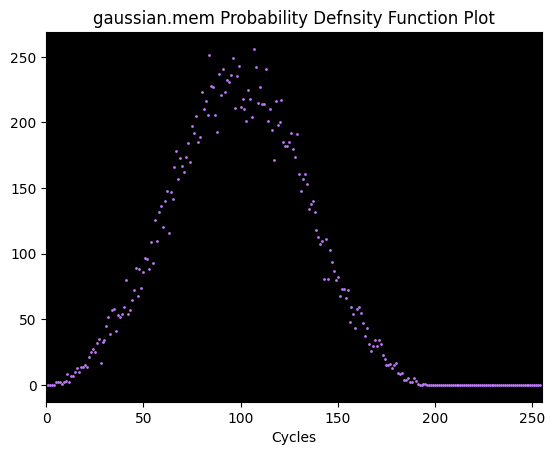

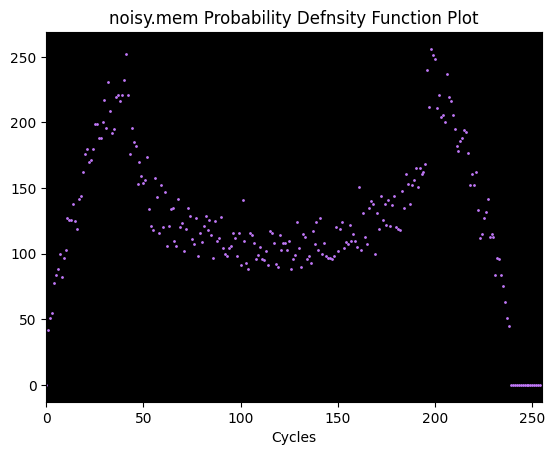

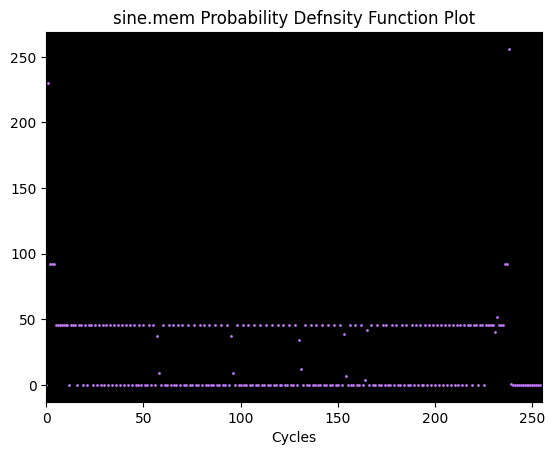

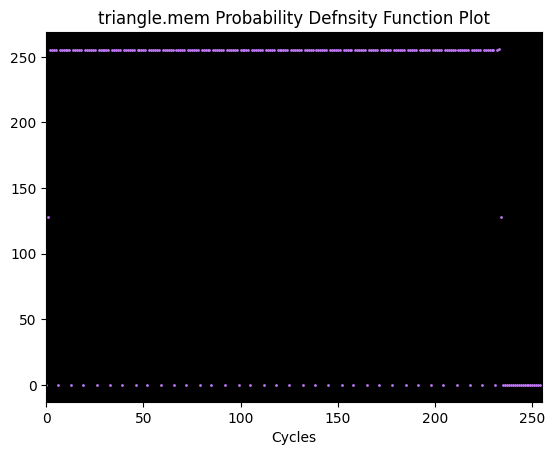

In [45]:
X_AXIS = [i for i in range(255)]
FUNC_PDF = {
    "gaussian": gaussian_pdf, 
    "noisy": noisy_pdf, 
    "sine": sine_pdf,
    "triangle": triangle_pdf
}

def vbuddy_image(name: str):
    fig, ax = plt.subplots()
    fig.set_facecolor("xkcd:white")
    ax.scatter(X_AXIS, FUNC_PDF[name], s=1, c="xkcd:light purple")
    ax.set(xlim=(0, 255))
    ax.set_facecolor("xkcd:black")
    plt.title(f"{name}.mem Probability Defnsity Function Plot")
    plt.xlabel('Cycles')
    plt.show()
    
plt.rcParams["figure.figsize"] = [6.4, 4.8]

vbuddy_image("gaussian")
vbuddy_image("noisy")
vbuddy_image("sine")
vbuddy_image("triangle")

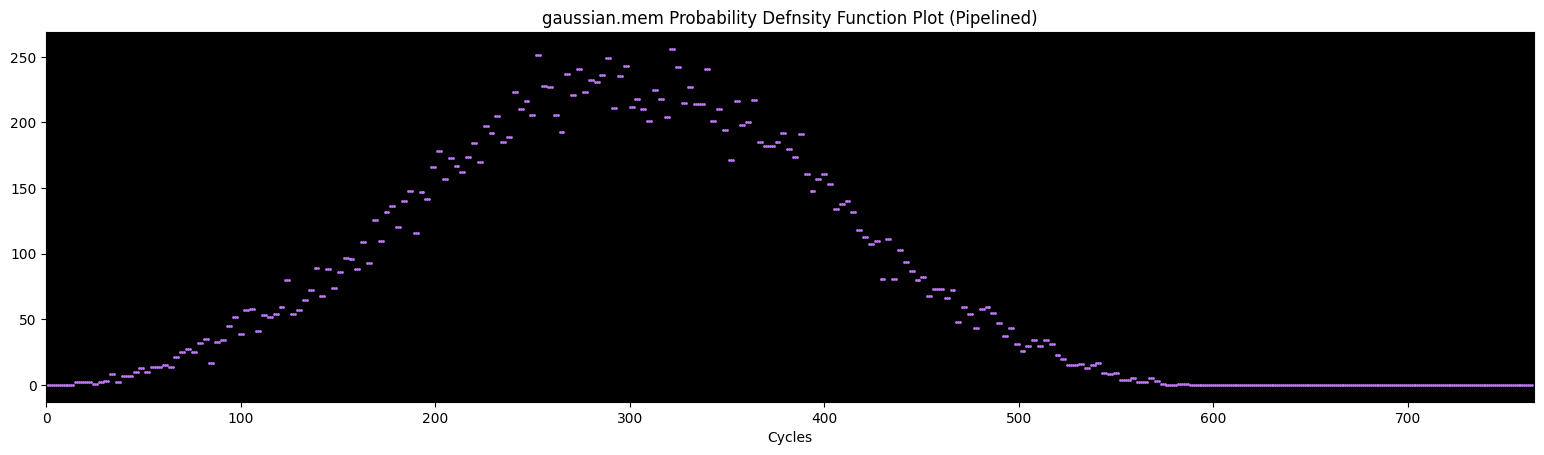

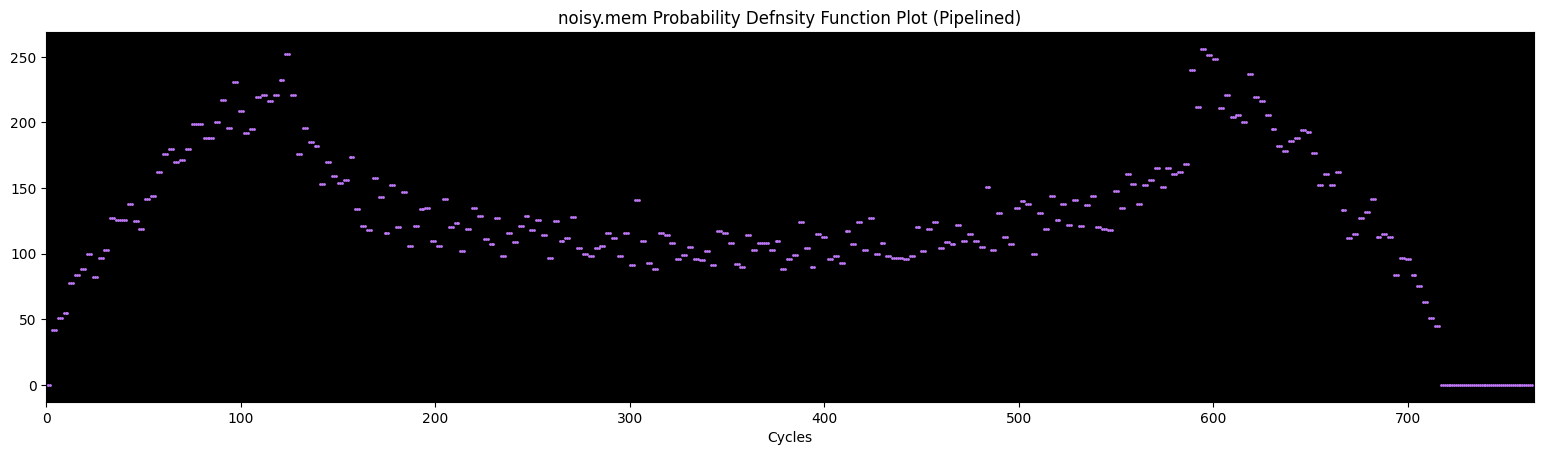

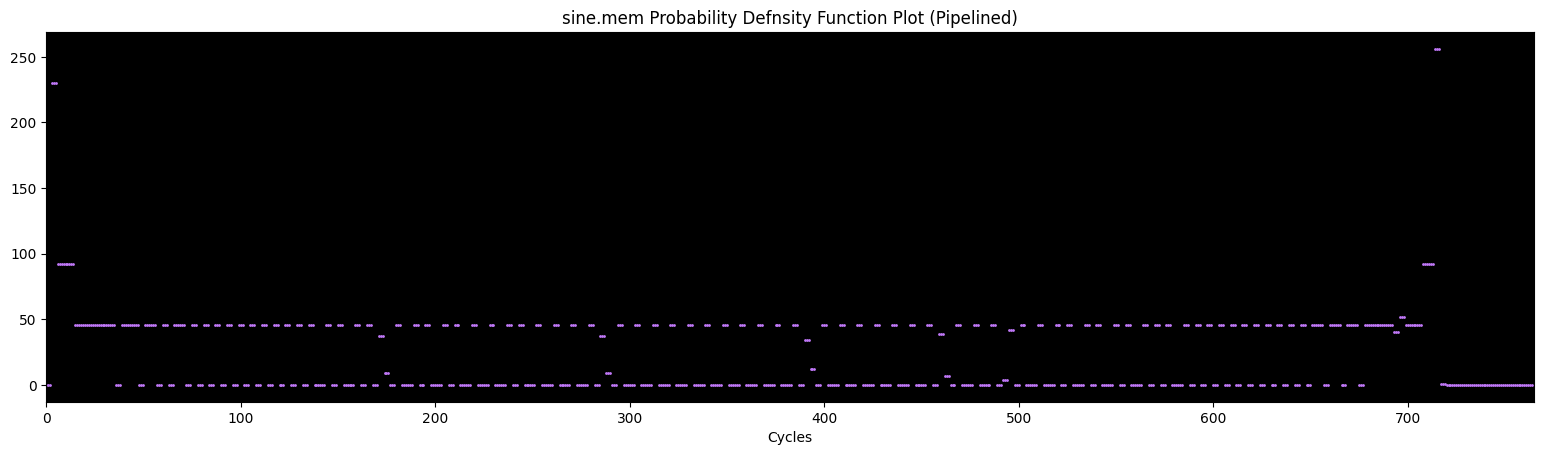

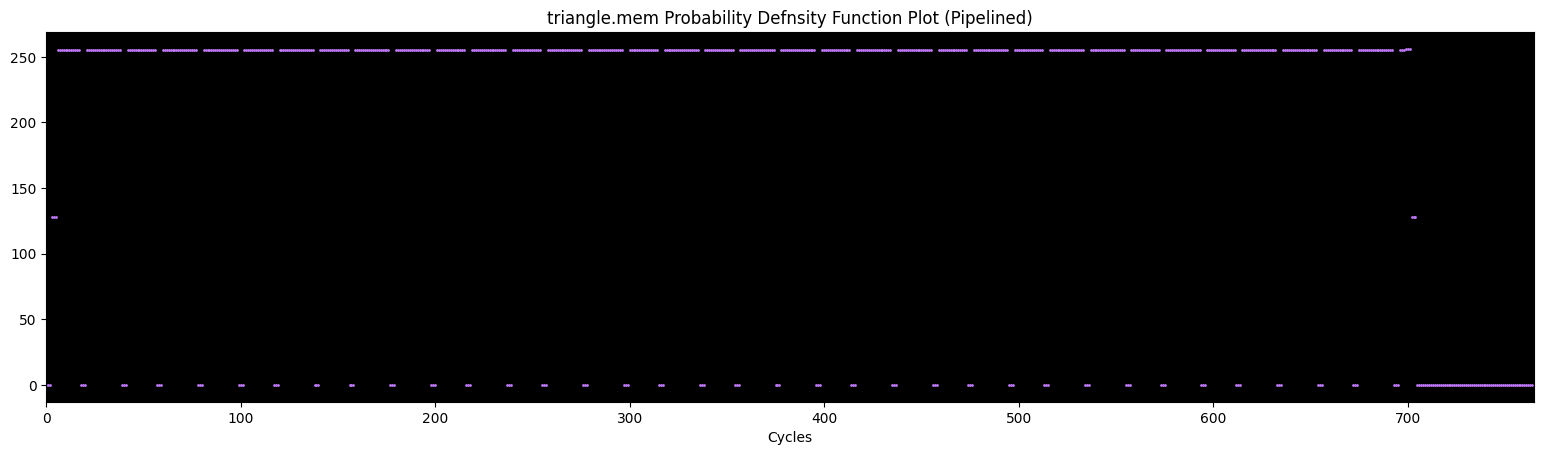

In [46]:
def process_data_pipeline(data: List[int], ac: int = 3) -> List[int]:
    # ac: additional cycle length
    # pd: pipeline data
    pd = []
    for item in data:
        for i in range (ac):
            pd.append(item)
    return pd

FUNC_PDF_PIP = {
    "gaussian": process_data_pipeline(gaussian_pdf), 
    "noisy": process_data_pipeline(noisy_pdf), 
    "sine": process_data_pipeline(sine_pdf),
    "triangle": process_data_pipeline(triangle_pdf)
}

def vbuddy_image_pipeline(name: str, ac: int = 3):
    fig, ax = plt.subplots()
    fig.set_facecolor("xkcd:white")
    ax.scatter([i for i in range(255*ac)], FUNC_PDF_PIP[name], s=1, c="xkcd:light purple")
    ax.set(xlim=(0, 255*ac))
    ax.set_facecolor("xkcd:black")
    plt.title(f"{name}.mem Probability Defnsity Function Plot (Pipelined)")
    plt.xlabel('Cycles')
    plt.show()
    
plt.rcParams["figure.figsize"] = [6.4*3, 4.8]

vbuddy_image_pipeline("gaussian")
vbuddy_image_pipeline("noisy")
vbuddy_image_pipeline("sine")
vbuddy_image_pipeline("triangle")